In [2]:
# necessary imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('data/StudentPerformanceFactors.csv')

In [4]:
# basic overview of dataset
df.head

<bound method NDFrame.head of       Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0                23          84                  Low                High   
1                19          64                  Low              Medium   
2                24          98               Medium              Medium   
3                29          89                  Low              Medium   
4                19          92               Medium              Medium   
...             ...         ...                  ...                 ...   
6602             25          69                 High              Medium   
6603             23          76                 High              Medium   
6604             20          90               Medium                 Low   
6605             10          86                 High                High   
6606             15          67               Medium                 Low   

     Extracurricular_Activities  Sleep_Hours  Previous_Sc

In [5]:
# see data types of the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [6]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [7]:
df.shape

(6607, 20)

In [8]:
# find columns that contain missing values
df.isnull().sum().sort_values(ascending=False)

Parental_Education_Level      90
Teacher_Quality               78
Distance_from_Home            67
Hours_Studied                  0
Access_to_Resources            0
Parental_Involvement           0
Attendance                     0
Extracurricular_Activities     0
Motivation_Level               0
Internet_Access                0
Previous_Scores                0
Sleep_Hours                    0
Family_Income                  0
Tutoring_Sessions              0
School_Type                    0
Peer_Influence                 0
Learning_Disabilities          0
Physical_Activity              0
Gender                         0
Exam_Score                     0
dtype: int64

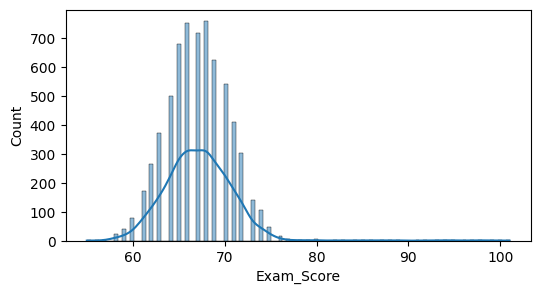

In [9]:
# check for validity / sanity of scores, seems to be ok
target = 'Exam_Score' # easier and less likely to mistake the name of the column
plt.figure(figsize = (6, 3))
sns.histplot(df[target], kde = True)
plt.show()

In [10]:
# find columns / factors which greatly influence the results of the students - start with numerical columns
numeric_df = df.select_dtypes(include=np.number) 
corr = numeric_df.corr()[target].sort_values(ascending=False) # find correlation with numeric values
corr

Exam_Score           1.000000
Attendance           0.581072
Hours_Studied        0.445455
Previous_Scores      0.175079
Tutoring_Sessions    0.156525
Physical_Activity    0.027824
Sleep_Hours         -0.017022
Name: Exam_Score, dtype: float64

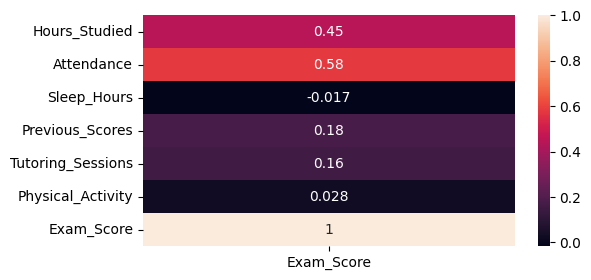

In [11]:
plt.figure(figsize = (6, 3))
sns.heatmap (
    numeric_df.corr()[[target]], # 2 [[]] to make the result from a series to a dataframe
    annot = True,
)
plt.show() # conclusion, we are most interested in attendance, hours studied and previous scores

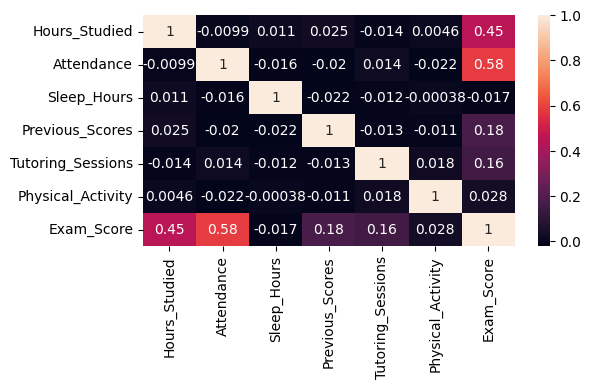

In [12]:
# we can also see that, at least for the numerical columns, there is little correlation between them
corrMatrix = df.corr(numeric_only = True)
plt.figure(figsize = (6, 3))
sns.heatmap(corrMatrix, annot = True)
plt.show()

In [13]:
# for non-numerical categories, we can visualize the mean from each category
cat_cols = df.select_dtypes(include=['object', 'category', 'bool', 'str']).columns

for col in cat_cols:
    print(f"\n{col}")
    print(df.groupby(col)[target].mean().sort_values(ascending=False))


Parental_Involvement
Parental_Involvement
High      68.092767
Medium    67.098156
Low       66.358265
Name: Exam_Score, dtype: float64

Access_to_Resources
Access_to_Resources
High      68.092152
Medium    67.134378
Low       66.203351
Name: Exam_Score, dtype: float64

Extracurricular_Activities
Extracurricular_Activities
Yes    67.441849
No     66.931435
Name: Exam_Score, dtype: float64

Motivation_Level
Motivation_Level
High      67.704321
Medium    67.330648
Low       66.752194
Name: Exam_Score, dtype: float64

Internet_Access
Internet_Access
Yes    67.292895
No     66.535070
Name: Exam_Score, dtype: float64

Family_Income
Family_Income
High      67.842396
Medium    67.334959
Low       66.848428
Name: Exam_Score, dtype: float64

Teacher_Quality
Teacher_Quality
High      67.676939
Medium    67.109299
Low       66.753425
Name: Exam_Score, dtype: float64

School_Type
School_Type
Private    67.287705
Public     67.212919
Name: Exam_Score, dtype: float64

Peer_Influence
Peer_Influence
P

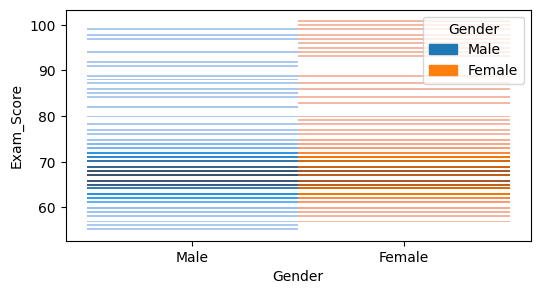

In [14]:
plt.figure(figsize = (6, 3)) # as we can see, gender plays a small part in the exam results
sns.histplot(x='Gender', y=target, data=df, hue='Gender', multiple='stack')
plt.show()

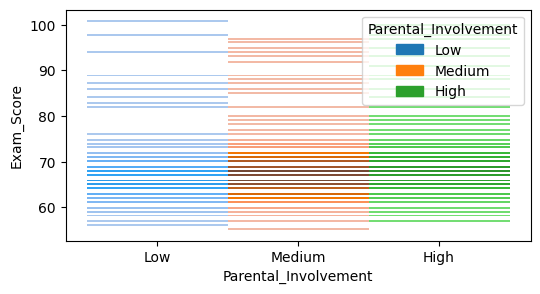

In [15]:
plt.figure(figsize = (6, 3)) # however, elements like learning disabilities, access to resources and parental involvement play key roles in the results of the students
sns.histplot(x='Parental_Involvement', y=target, data=df, hue='Parental_Involvement', multiple='stack')
plt.show()

In [16]:
# EDA conclusion: the factors that influence the student's grade the most are:
# hours studied, attendacnce, previous scores - numerical
# parental involvement, access to resources and the existance of a learning disability - string

In [17]:
# train an ML model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [18]:
# define our extra variables
X = df.drop(columns=[target])
y = df[target]

num_cols = X.select_dtypes(include="number").columns
cat_cols = X.select_dtypes(include=['object', 'string']).columns

In [19]:
# check for correct syntax - for my personal verification
cat_cols

Index(['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender'],
      dtype='str')

In [20]:
num_cols

Index(['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
       'Tutoring_Sessions', 'Physical_Activity'],
      dtype='str')

In [21]:
# preprocessing + model (baseline and random-forest, in this case random-forest underperforms the baseline, probably needs tuning and also 
# most realtionships are probably linear)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

baseline_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LinearRegression())
    ]
)

rf_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=300,
            random_state=42
        ))
    ]
)

In [22]:
# training + evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

baseline_model.fit(X_train, y_train)
base_predictions = baseline_model.predict(X_test)

rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, base_predictions))
print("R²:", r2_score(y_test, base_predictions))
print("RF MAE:", mean_absolute_error(y_test, rf_predictions))
print("RF R²:", r2_score(y_test, rf_predictions))

MAE: 0.44994950022706937
R²: 0.7699282240123634
RF MAE: 1.0857211296016136
RF R²: 0.6688775284514976


In [23]:
# now train a specialized model based on our assumptions on what columns influence the results the most
important_features = [
    "Hours_Studied",
    "Attendance",
    "Previous_Scores",
    "Parental_Involvement",
    "Access_to_Resources",
    "Learning_Disabilities"
]

X_imp = df[important_features]

X_train, X_test, y_train, y_test = train_test_split(
    X_imp, y, test_size=0.2, random_state=42
)

rf_imp = Pipeline(
    steps=[
        ("preprocess", ColumnTransformer(
            [
                ("num", "passthrough", X_imp.select_dtypes("number").columns),
                ("cat", OneHotEncoder(handle_unknown="ignore"),
                 X_imp.select_dtypes(["object", "string"]).columns)
            ]
        )),
        ("model", RandomForestRegressor(
            n_estimators=300,
            random_state=42
        ))
    ]
)

rf_imp.fit(X_train, y_train)
preds_imp = rf_imp.predict(X_test)

print("Focused RF MAE:", mean_absolute_error(y_test, preds_imp))
print("Focused RF R²:", r2_score(y_test, preds_imp))

Focused RF MAE: 1.3258571379452617
Focused RF R²: 0.5943085718076333


In [24]:
# conclusion: even though the model trained on the whole dataset outperforms the focused model, it is not a huge difference, 
# and it is only natural that with more data, precision will increase
# => our selected columns somewhat accurately desribe the future exam score for the student

In [25]:
# create a student with fictive data and let the model predict thier score
new_student = pd.DataFrame([{
    "Hours_Studied": 22,
    "Attendance": 88,
    "Parental_Involvement": "Medium",
    "Access_to_Resources": "High",
    "Extracurricular_Activities": "Yes",
    "Sleep_Hours": 7,
    "Previous_Scores": 78,
    "Motivation_Level": "Medium",
    "Internet_Access": "Yes",
    "Tutoring_Sessions": 2,
    "Family_Income": "Medium",
    "Teacher_Quality": "High",
    "School_Type": "Public",
    "Peer_Influence": "Positive",
    "Physical_Activity": 3,
    "Learning_Disabilities": "No",
    "Parental_Education_Level": "College",
    "Distance_from_Home": "Near",
    "Gender": "Female"
}])

predicted_score = baseline_model.predict(new_student)
print("Predicted score: ", predicted_score[0])

Predicted score:  72.40707679495264


In [31]:
# also test the model for accuracy predicting outliers - in this case, a bad student
bad_student = pd.DataFrame([{
    "Hours_Studied": 5,
    "Attendance": 60,
    "Parental_Involvement": "Low",
    "Access_to_Resources": "Low",
    "Extracurricular_Activities": "No",
    "Sleep_Hours": 7,
    "Previous_Scores": 50,
    "Motivation_Level": "Low",
    "Internet_Access": "No",
    "Tutoring_Sessions": 2,
    "Family_Income": "Low",
    "Teacher_Quality": "Low",
    "School_Type": "Public",
    "Peer_Influence": "Negative",
    "Physical_Activity": 3,
    "Learning_Disabilities": "No",
    "Parental_Education_Level": "High School",
    "Distance_from_Home": "Far",
    "Gender": "Male"
}])

bad_predicted_score = baseline_model.predict(bad_student)
print("Predicted score for bad student: ", bad_predicted_score[0])

Predicted score for bad student:  51.535493271582695


In [27]:
# Lastly, in order to suggest a set of suggestions for improving one's grade, we first have to define what variables / areas can be imrpoved:
# such as: Sleep_Hours, Attendance, Hours_Studied ...
# And not touch unchangeable variables such as: Gender, Family_Income etc.

In [28]:
suggestions = {
    "Increase study time (+5 hours)": {
        "Hours_Studied": new_student.loc[0, "Hours_Studied"] + 5
    },
    "Improve attendance to 95%": {
        "Attendance": 95
    },
    "Increase sleep to 8 hours": {
        "Sleep_Hours": 8
    },
    "Add 2 tutoring sessions": {
        "Tutoring_Sessions": new_student.loc[0, "Tutoring_Sessions"] + 2
    },
    "Increase motivation to High": {
        "Motivation_Level": "High"
    }
}

In [29]:
results = []

for name, changes in suggestions.items():
    modified = new_student.copy()
    
    for feature, value in changes.items():
        modified.loc[0, feature] = value
    
    new_score = baseline_model.predict(modified)[0]
    
    results.append({
        "Suggestion": name,
        "Predicted_Score": new_score,
        "Improvement": new_score - predicted_score
    })

results_df = pd.DataFrame(results).sort_values("Improvement", ascending=False)
results_df

,Suggestion,Predicted_Score,Improvement
0,Increase study time (+5 hours),73.872119,[1.4650418756706927]
1,Improve attendance to 95%,73.798431,[1.3913543387392906]
3,Add 2 tutoring sessions,73.423284,[1.016207450402021]
4,Increase motivation to High,72.958048,[0.5509711920191478]
2,Increase sleep to 8 hours,72.394388,[-0.012689059385962764]


In [30]:
# Conclusion: our model undervalues sleep hours, sadly
# Otherwise, this was a great learning opportunity and I am very glad to have been able to do this project